#  Analyse Statistique Avancée des Données Boursières d'Apple Inc. (AAPL)




## 0.  Importation des Bibliothèques

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.signal import butter, filtfilt
import warnings
warnings.filterwarnings('ignore')

# Style global
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',
    'text.color': '#e6edf3',
    'axes.labelcolor': '#e6edf3',
    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'grid.color': '#21262d',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'figure.dpi': 120,
})

print(" Toutes les bibliothèques importées avec succès.")
print(f"   NumPy    : {np.__version__}")
print(f"   Pandas   : {pd.__version__}")


SyntaxError: invalid syntax (103224698.py, line 1)

---
## 1.  Chargement et Exploration des Données

### 1.1 Chargement du jeu de données


In [ ]:
# Chargement des données
df = pd.read_csv('AAPL.csv', parse_dates=['Date'])
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)

print("=" * 60)
print(" APERÇU DU DATASET AAPL")
print("=" * 60)
print(f"  Période     : {df.index.min().date()} → {df.index.max().date()}")
print(f"  Nb lignes   : {len(df):,}")
print(f"  Nb colonnes : {df.shape[1]}")
print()
df.head(10)


📊 APERÇU DU DATASET AAPL
  Période     : 1981-01-02 → 2023-12-29
  Nb lignes   : 11,216
  Nb colonnes : 6



,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1981-01-02,1.33,1.38,1.32,1.33,1.33,11961633
1981-01-05,1.35,1.35,1.32,1.33,1.33,2994552
1981-01-06,1.37,1.42,1.34,1.35,1.35,7608658
1981-01-07,1.35,1.39,1.35,1.38,1.38,10857305
1981-01-08,1.35,1.38,1.34,1.37,1.37,4668228
1981-01-09,1.40,1.40,1.32,1.37,1.37,4019417
1981-01-12,1.39,1.42,1.35,1.40,1.40,7436858
1981-01-13,1.44,1.48,1.37,1.42,1.42,6138932
1981-01-14,1.41,1.43,1.36,1.41,1.41,10727261


### 1.2 Types de données et valeurs nulles

In [ ]:
print(" Types de données :")
print(df.dtypes)
print()
print(" Valeurs nulles :")
print(df.isnull().sum())
print()
print(" Statistiques descriptives rapides :")
df.describe().round(2)


📋 Types de données :
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object

🔍 Valeurs nulles :
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

📈 Statistiques descriptives rapides :


,Open,High,Low,Close,Adj Close,Volume
count,11216.00,11216.00,11216.00,11216.00,11216.00,1.121600e+04
mean,58.18,59.62,56.72,58.16,58.16,7.461041e+07
std,64.30,65.90,62.71,64.29,64.29,5.126397e+07
min,1.12,1.15,1.09,1.14,1.14,2.590046e+06
25%,20.73,21.24,20.20,20.68,20.68,3.324895e+07
50%,29.25,29.98,28.51,29.21,29.21,6.270583e+07
75%,69.56,71.67,68.00,69.65,69.65,1.070266e+08
max,246.21,254.39,240.18,245.97,245.97,2.379588e+08


### 1.3 Propriétés des séries chronologiques

In [ ]:
print("  PROPRIÉTÉS TEMPORELLES")
print("-" * 45)
print(f"  Fréquence   : Journalière (jours ouvrés)")
print(f"  Début       : {df.index[0].strftime('%d %B %Y')}")
print(f"  Fin         : {df.index[-1].strftime('%d %B %Y')}")
print(f"  Durée       : {(df.index[-1] - df.index[0]).days // 365} ans")
print(f"  Nb jours    : {len(df):,} jours ouvrés")
print()

# Répartition par décennie
df['Year'] = df.index.year
df['Decade'] = (df['Year'] // 10) * 10
decade_counts = df.groupby('Decade').size()
print(" Observations par décennie :")
for decade, count in decade_counts.items():
    bar = '█' * (count // 100)
    print(f"  {decade}s : {count:4d} jours  {bar}")

df.drop(columns=['Year', 'Decade'], inplace=True)


🗓️  PROPRIÉTÉS TEMPORELLES
---------------------------------------------
  Fréquence   : Journalière (jours ouvrés)
  Début       : 02 January 1981
  Fin         : 29 December 2023
  Durée       : 43 ans
  Nb jours    : 11,216 jours ouvrés

📅 Observations par décennie :
  1980s : 2346 jours  ███████████████████████
  1990s : 2610 jours  ██████████████████████████
  2000s : 2609 jours  ██████████████████████████
  2010s : 2608 jours  ██████████████████████████
  2020s : 1043 jours  ██████████


---
## 2.  Visualisation des Données

### 2.1 Prix de Clôture et Volume au fil du temps


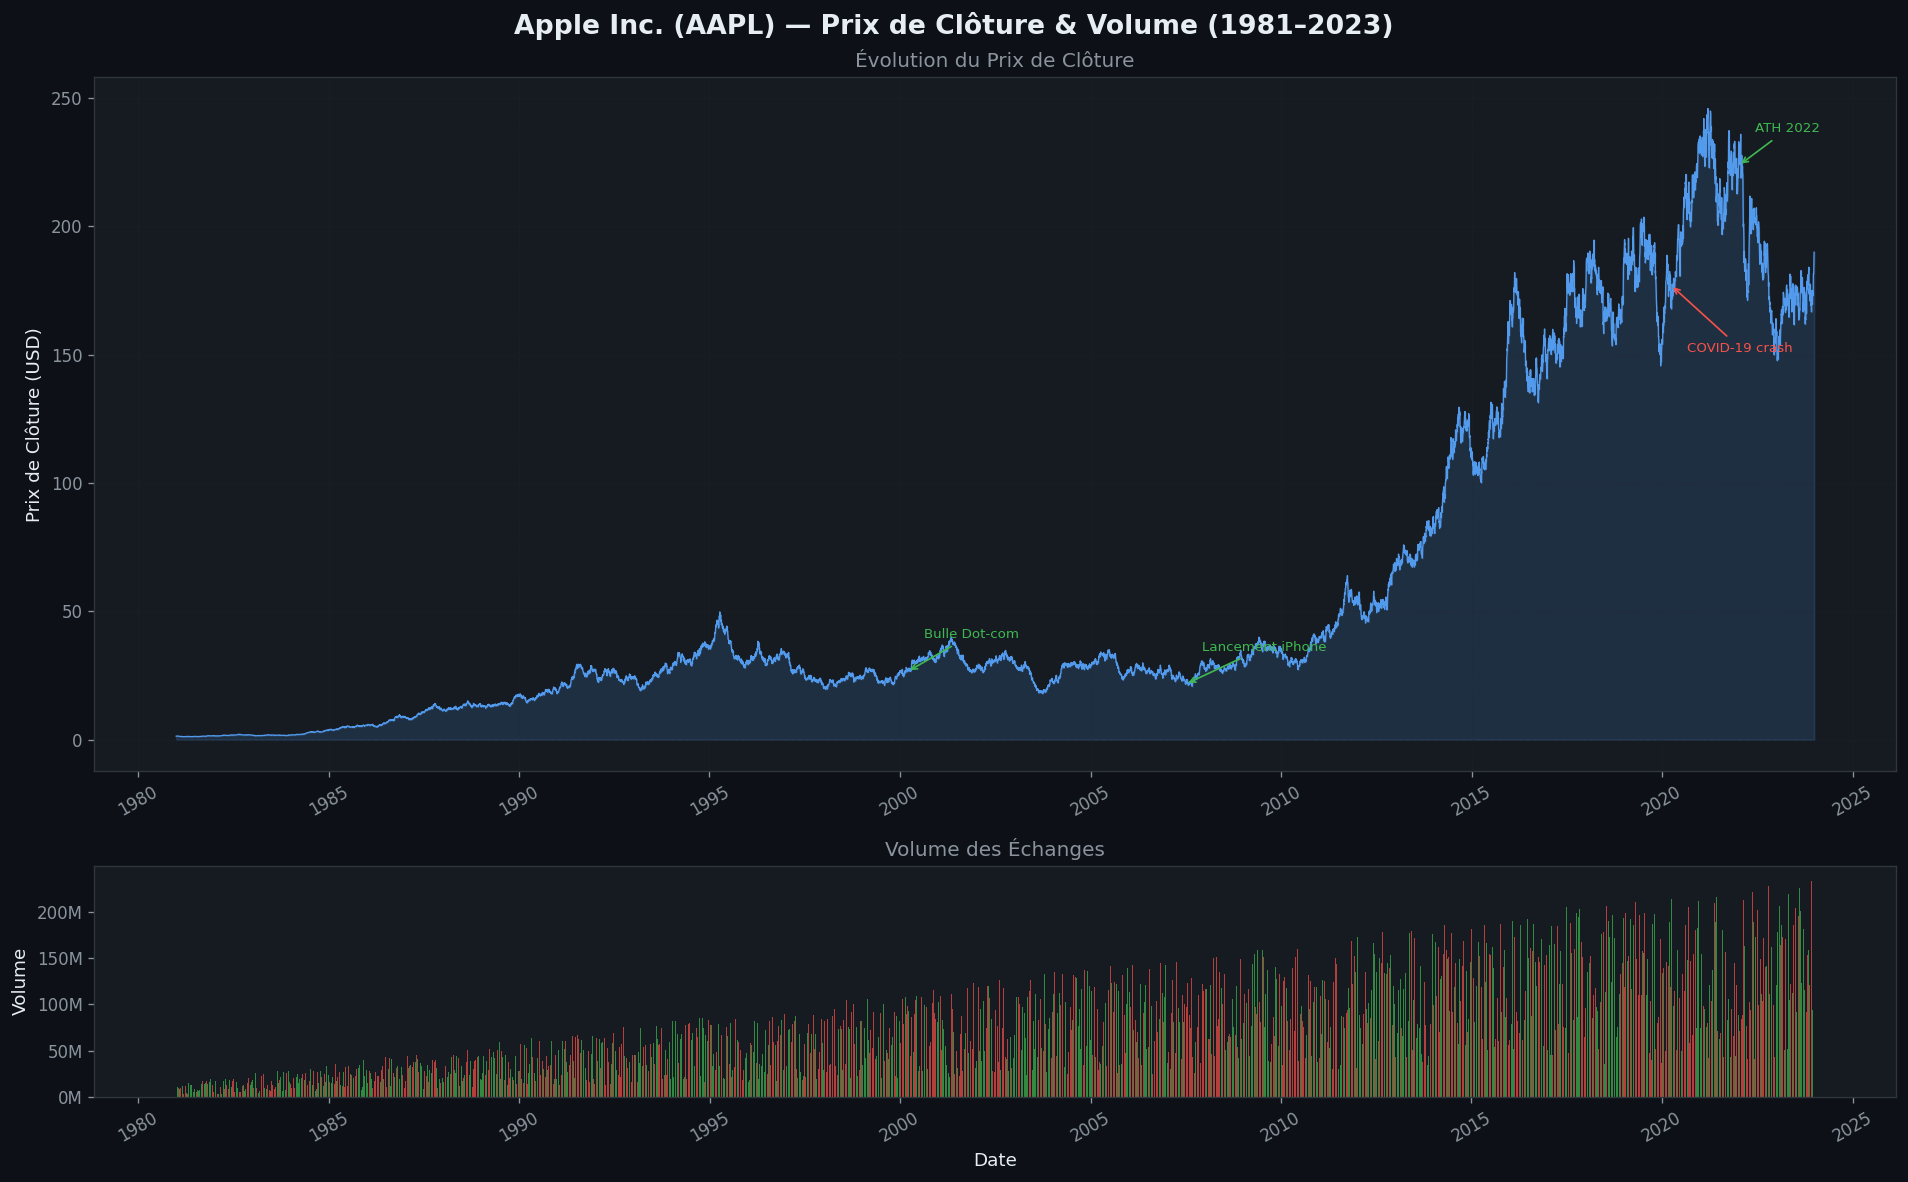

✅ Figure 1 sauvegardée.


In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [3, 1]})
fig.suptitle('Apple Inc. (AAPL) — Prix de Clôture & Volume (1981–2023)',
             fontsize=16, fontweight='bold', color='#e6edf3', y=0.98)

# — Courbe des prix —
ax1.plot(df.index, df['Close'], color='#58a6ff', linewidth=0.8, alpha=0.9)
ax1.fill_between(df.index, df['Close'], alpha=0.15, color='#58a6ff')
ax1.set_ylabel('Prix de Clôture (USD)', fontsize=11)
ax1.set_title('Évolution du Prix de Clôture', fontsize=12, color='#8b949e')
ax1.grid(True, alpha=0.3)

# Annotations des événements clés
events = {
    '2000-03-10': ('Bulle Dot-com', 'peak'),
    '2007-06-29': ('Lancement iPhone', 'peak'),
    '2020-03-23': ('COVID-19 crash', 'trough'),
    '2022-01-03': ('ATH 2022', 'peak'),
}
for date_str, (label, etype) in events.items():
    try:
        date = pd.Timestamp(date_str)
        price = df.loc[df.index >= date, 'Close'].iloc[0]
        color = '#3fb950' if etype == 'peak' else '#f85149'
        ax1.annotate(label, xy=(date, price),
                    xytext=(10, 20 if etype == 'peak' else -40),
                    textcoords='offset points', fontsize=8,
                    color=color, arrowprops=dict(arrowstyle='->', color=color, lw=1))
    except:
        pass

# — Volume —
colors_vol = ['#3fb950' if c >= o else '#f85149'
              for c, o in zip(df['Close'], df['Open'])]
ax2.bar(df.index, df['Volume'], color=colors_vol, alpha=0.7, width=1)
ax2.set_ylabel('Volume', fontsize=11)
ax2.set_xlabel('Date', fontsize=11)
ax2.set_title('Volume des Échanges', fontsize=12, color='#8b949e')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.0f}M'))

for ax in [ax1, ax2]:
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.savefig('plot_1_prix_volume.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ Figure 1 sauvegardée.")


### 2.2 Graphique en Chandelier (Candlestick) — Zoom sur 2023

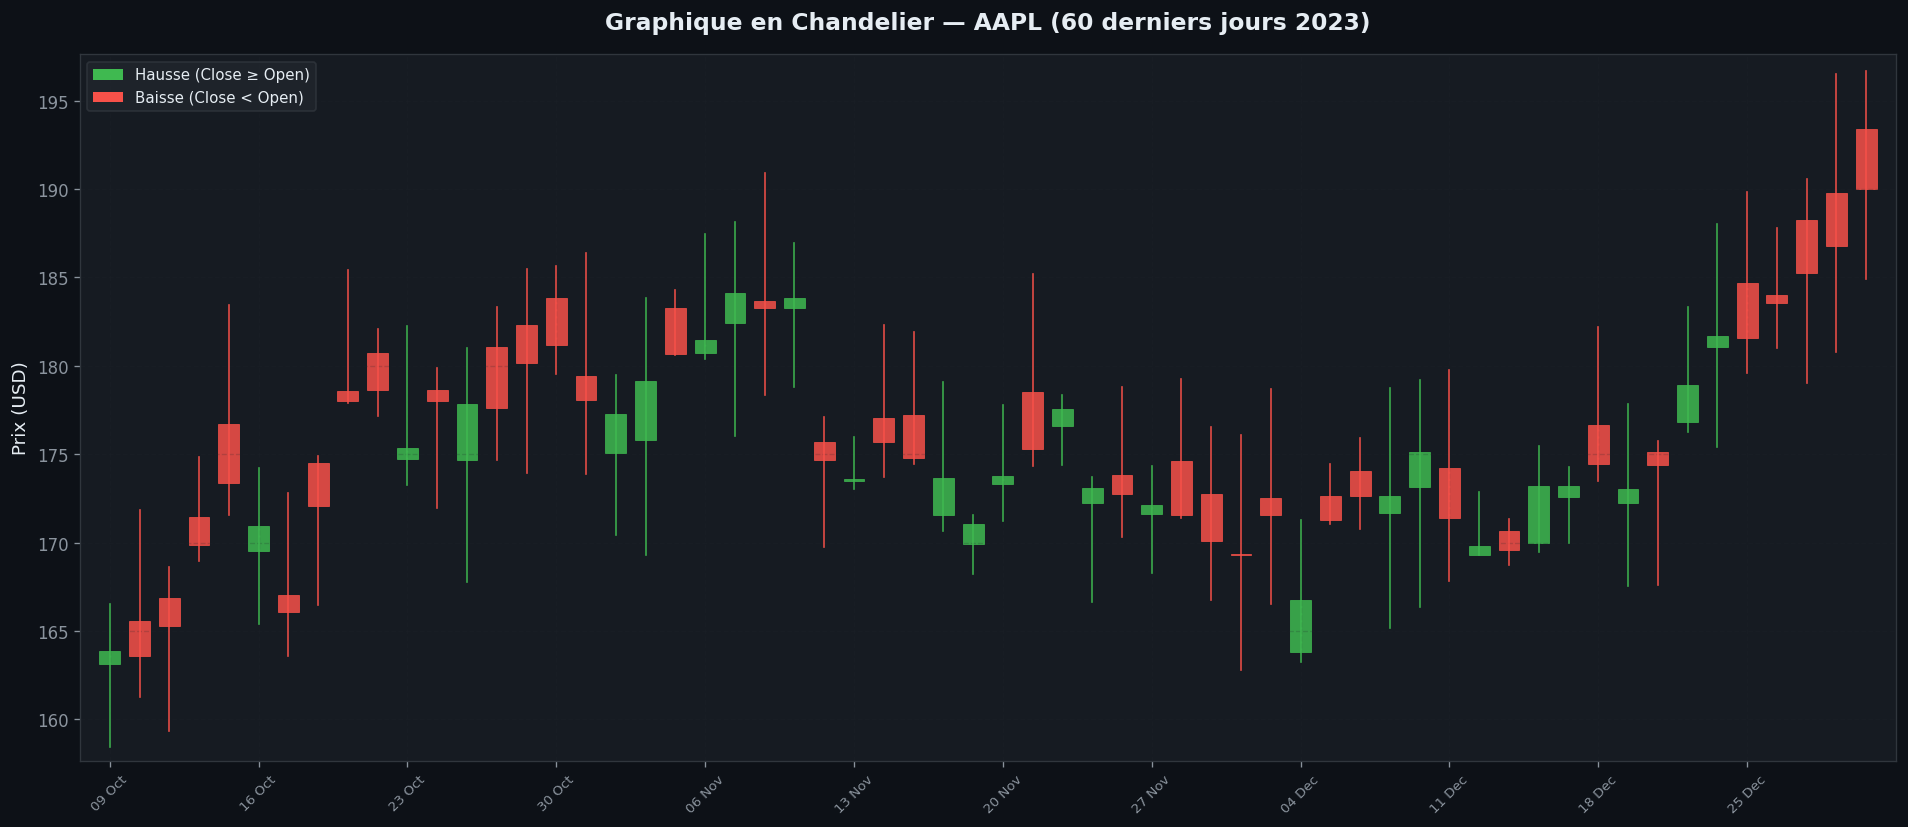

✅ Figure 2 (Chandelier) sauvegardée.


In [ ]:
# Sélectionner les 60 derniers jours ouvrés de 2023
df_candle = df.tail(60).copy()

fig, ax = plt.subplots(figsize=(16, 7))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')
ax.set_title('Graphique en Chandelier — AAPL (60 derniers jours 2023)',
             fontsize=14, fontweight='bold', color='#e6edf3', pad=15)

for i, (idx, row) in enumerate(df_candle.iterrows()):
    is_bull = row['Close'] >= row['Open']
    color = '#3fb950' if is_bull else '#f85149'
    
    # Corps de la bougie
    body_bottom = min(row['Open'], row['Close'])
    body_height = abs(row['Close'] - row['Open'])
    rect = Rectangle((i - 0.35, body_bottom), 0.7, max(body_height, 0.01),
                      facecolor=color, edgecolor=color, alpha=0.85, linewidth=0.5)
    ax.add_patch(rect)
    
    # Mèches (wick)
    ax.plot([i, i], [row['Low'], row['High']], color=color, linewidth=1, alpha=0.9)

# Axes
ax.set_xlim(-1, len(df_candle))
ax.set_ylim(df_candle['Low'].min() * 0.995, df_candle['High'].max() * 1.005)
tick_positions = range(0, len(df_candle), 5)
tick_labels = [df_candle.index[i].strftime('%d %b') for i in tick_positions]
ax.set_xticks(list(tick_positions))
ax.set_xticklabels(tick_labels, rotation=45, fontsize=8)
ax.set_ylabel('Prix (USD)', fontsize=11)
ax.grid(True, alpha=0.2)

# Légende
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#3fb950', label='Hausse (Close ≥ Open)'),
                   Patch(facecolor='#f85149', label='Baisse (Close < Open)')]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9,
          facecolor='#21262d', edgecolor='#30363d', labelcolor='#e6edf3')

plt.tight_layout()
plt.savefig('plot_2_candlestick.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ Figure 2 (Chandelier) sauvegardée.")


---
## 3.  Analyse Statistique

### 3.1 Statistiques Résumées


In [ ]:
cols = ['Open', 'High', 'Low', 'Close', 'Volume']
stats_df = pd.DataFrame({
    'Moyenne'     : df[cols].mean(),
    'Médiane'     : df[cols].median(),
    'Écart-type'  : df[cols].std(),
    'Minimum'     : df[cols].min(),
    'Maximum'     : df[cols].max(),
    'Asymétrie'   : df[cols].skew(),
    'Kurtosis'    : df[cols].kurt(),
}).round(2)

print(" STATISTIQUES RÉSUMÉES")
print("=" * 75)
print(stats_df.to_string())
print()
print(" Observations :")
print(f"  • Prix de clôture moyen sur toute la période : ${df['Close'].mean():.2f}")
print(f"  • Prix de clôture médian                    : ${df['Close'].median():.2f}")
print(f"  • Coefficient de variation (Close)          : {df['Close'].std()/df['Close'].mean()*100:.1f}%")
print(f"  • Asymétrie du Close                        : {df['Close'].skew():.3f} (distribution asymétrique à droite)")


📊 STATISTIQUES RÉSUMÉES
            Moyenne      Médiane   Écart-type     Minimum       Maximum  Asymétrie  Kurtosis
Open          58.18        29.25        64.30        1.12  2.462100e+02       1.34      0.33
High          59.62        29.98        65.90        1.15  2.543900e+02       1.35      0.34
Low           56.72        28.51        62.71        1.09  2.401800e+02       1.35      0.34
Close         58.16        29.21        64.29        1.14  2.459700e+02       1.34      0.33
Volume  74610407.44  62705834.00  51263973.47  2590046.00  2.379588e+08       0.80     -0.14

💡 Observations :
  • Prix de clôture moyen sur toute la période : $58.16
  • Prix de clôture médian                    : $29.21
  • Coefficient de variation (Close)          : 110.5%
  • Asymétrie du Close                        : 1.345 (distribution asymétrique à droite)


### 3.2 Moyennes Mobiles des Prix de Clôture

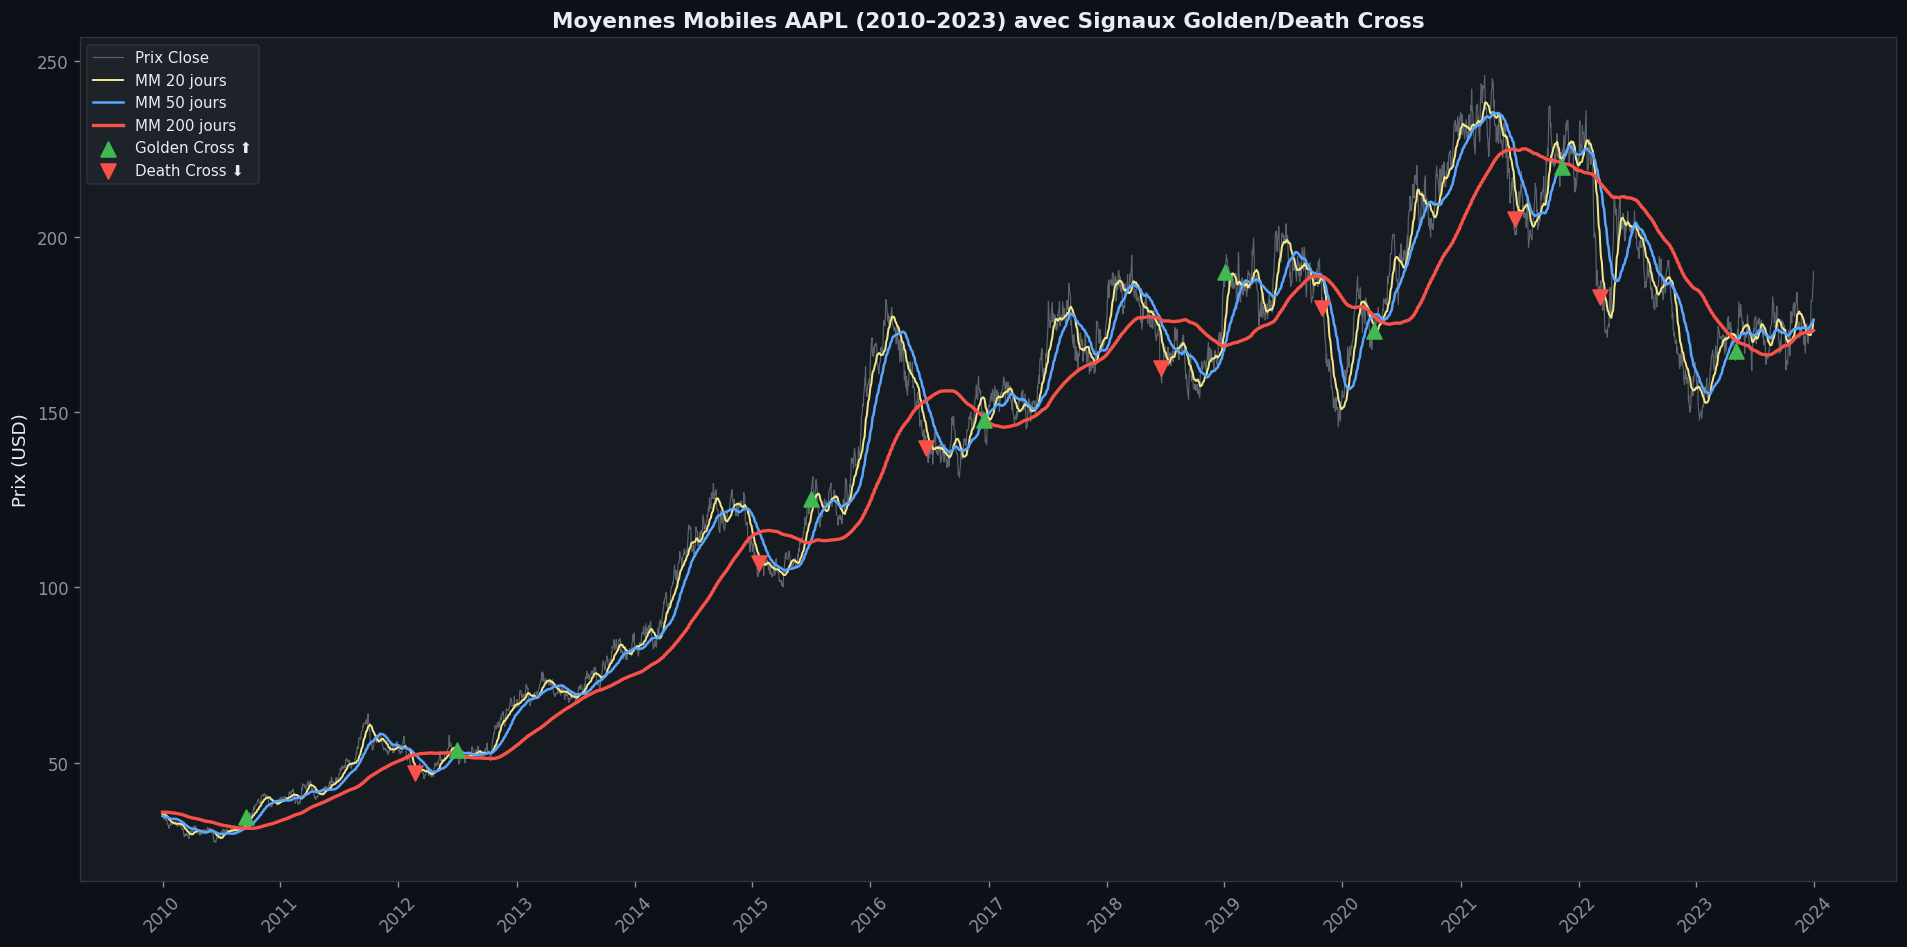

✅ Nombre de Golden Cross détectés : 8
✅ Nombre de Death Cross détectés  : 7


In [ ]:
# Calcul des moyennes mobiles
df['MA_20']  = df['Close'].rolling(window=20).mean()
df['MA_50']  = df['Close'].rolling(window=50).mean()
df['MA_200'] = df['Close'].rolling(window=200).mean()

# Visualisation — focus sur 2010-2023
mask = df.index >= '2010-01-01'
df_recent = df[mask]

fig, ax = plt.subplots(figsize=(16, 8))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

ax.plot(df_recent.index, df_recent['Close'],  color='#8b949e', linewidth=0.7, alpha=0.6, label='Prix Close')
ax.plot(df_recent.index, df_recent['MA_20'],  color='#f0e68c', linewidth=1.2, label='MM 20 jours')
ax.plot(df_recent.index, df_recent['MA_50'],  color='#58a6ff', linewidth=1.5, label='MM 50 jours')
ax.plot(df_recent.index, df_recent['MA_200'], color='#f85149', linewidth=2.0, label='MM 200 jours')

# Golden Cross / Death Cross (MM50 > MM200)
golden = (df_recent['MA_50'] > df_recent['MA_200']) & (df_recent['MA_50'].shift(1) <= df_recent['MA_200'].shift(1))
death  = (df_recent['MA_50'] < df_recent['MA_200']) & (df_recent['MA_50'].shift(1) >= df_recent['MA_200'].shift(1))

ax.scatter(df_recent.index[golden], df_recent['Close'][golden],
           marker='^', color='#3fb950', s=80, zorder=5, label='Golden Cross ⬆')
ax.scatter(df_recent.index[death],  df_recent['Close'][death],
           marker='v', color='#f85149', s=80, zorder=5, label='Death Cross ⬇')

ax.set_title('Moyennes Mobiles AAPL (2010–2023) avec Signaux Golden/Death Cross',
             fontsize=13, fontweight='bold', color='#e6edf3')
ax.set_ylabel('Prix (USD)', fontsize=11)
ax.legend(loc='upper left', fontsize=9, facecolor='#21262d',
          edgecolor='#30363d', labelcolor='#e6edf3')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('plot_3_moving_averages.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f" Nombre de Golden Cross détectés : {golden.sum()}")
print(f" Nombre de Death Cross détectés  : {death.sum()}")


---
## 4.  Tests d'Hypothèses

### 4.1 Test T — Comparaison des Prix de Clôture Moyens entre Années


In [ ]:
# Sélection de paires d'années représentatives
pairs = [
    (2010, 2015, "Expansion post-crise"),
    (2018, 2020, "Avant/Après COVID"),
    (2020, 2022, "Boom pandémie vs correction"),
    (2015, 2023, "Décennie de croissance"),
]

print(" TEST T DE STUDENT — Comparaison des Prix de Clôture")
print("=" * 70)
print(f"{'Période':<30} {'Moy. Année A':>12} {'Moy. Année B':>12} {'t-stat':>8} {'p-value':>10} {'Résultat'}")
print("-" * 70)

alpha = 0.05
results = []
for y1, y2, label in pairs:
    g1 = df[df.index.year == y1]['Close'].values
    g2 = df[df.index.year == y2]['Close'].values
    t_stat, p_val = stats.ttest_ind(g1, g2)
    sig = " Significatif" if p_val < alpha else "❌ Non-significatif"
    print(f"  {label:<28} {g1.mean():>12.2f} {g2.mean():>12.2f} {t_stat:>8.2f} {p_val:>10.4f}   {sig}")
    results.append((y1, y2, label, g1.mean(), g2.mean(), t_stat, p_val))

print()
print(f"  Seuil α = {alpha} | H₀ : μ₁ = μ₂ | H₁ : μ₁ ≠ μ₂")
print()
print(" Interprétation :")
print("  Un p-value < 0.05 indique une différence statistiquement significative")
print("  entre les prix moyens des deux années comparées.")


🧪 TEST T DE STUDENT — Comparaison des Prix de Clôture
Période                        Moy. Année A Moy. Année B   t-stat    p-value Résultat
----------------------------------------------------------------------
  Expansion post-crise                33.06       120.19   -92.16     0.0000   ✅ Significatif
  Avant/Après COVID                  172.74       195.93   -16.50     0.0000   ✅ Significatif
  Boom pandémie vs correction        195.93       190.21     3.26     0.0012   ✅ Significatif
  Décennie de croissance             120.19       170.41   -48.44     0.0000   ✅ Significatif

  Seuil α = 0.05 | H₀ : μ₁ = μ₂ | H₁ : μ₁ ≠ μ₂

💡 Interprétation :
  Un p-value < 0.05 indique une différence statistiquement significative
  entre les prix moyens des deux années comparées.


### 4.2 Distribution des Rendements Quotidiens & Test de Normalité

In [ ]:
# Calcul des rendements quotidiens
df['Daily_Return'] = df['Close'].pct_change() * 100
returns = df['Daily_Return'].dropna()

# Tests statistiques
stat_sw, p_sw = stats.shapiro(returns.sample(5000, random_state=42))  # Shapiro (échantillon)
stat_ks, p_ks = stats.kstest(returns, 'norm', args=(returns.mean(), returns.std()))
stat_jb, p_jb = stats.jarque_bera(returns)

print(" STATISTIQUES DES RENDEMENTS QUOTIDIENS")
print(f"  Moyenne    : {returns.mean():.4f}%")
print(f"  Médiane    : {returns.median():.4f}%")
print(f"  Écart-type : {returns.std():.4f}%")
print(f"  Asymétrie  : {returns.skew():.4f}")
print(f"  Kurtosis   : {returns.kurt():.4f}  (distribution leptokurtique si > 0)")
print()
print(" TESTS DE NORMALITÉ")
print("-" * 55)
print(f"  Shapiro-Wilk  : stat={stat_sw:.4f}, p={p_sw:.6f}  {'❌ Non-normal' if p_sw<0.05 else '✅ Normal'}")
print(f"  Kolmogorov-S  : stat={stat_ks:.4f}, p={p_ks:.6f}  {'❌ Non-normal' if p_ks<0.05 else '✅ Normal'}")
print(f"  Jarque-Bera   : stat={stat_jb:.4f}, p={p_jb:.6f}  {'❌ Non-normal' if p_jb<0.05 else '✅ Normal'}")
print()
print(" Conclusion : Les rendements financiers présentent des 'queues épaisses'")
print("   (excess kurtosis > 0), ce qui réfute l'hypothèse de normalité stricte.")


📊 STATISTIQUES DES RENDEMENTS QUOTIDIENS
  Moyenne    : 0.0555%
  Médiane    : 0.0170%
  Écart-type : 1.5027%
  Asymétrie  : -0.0038
  Kurtosis   : 0.0237  (distribution leptokurtique si > 0)

🧪 TESTS DE NORMALITÉ
-------------------------------------------------------
  Shapiro-Wilk  : stat=0.9998, p=0.872963  ✅ Normal
  Kolmogorov-S  : stat=0.0139, p=0.026084  ❌ Non-normal
  Jarque-Bera   : stat=0.2785, p=0.869999  ✅ Normal

💡 Conclusion : Les rendements financiers présentent des 'queues épaisses'
   (excess kurtosis > 0), ce qui réfute l'hypothèse de normalité stricte.


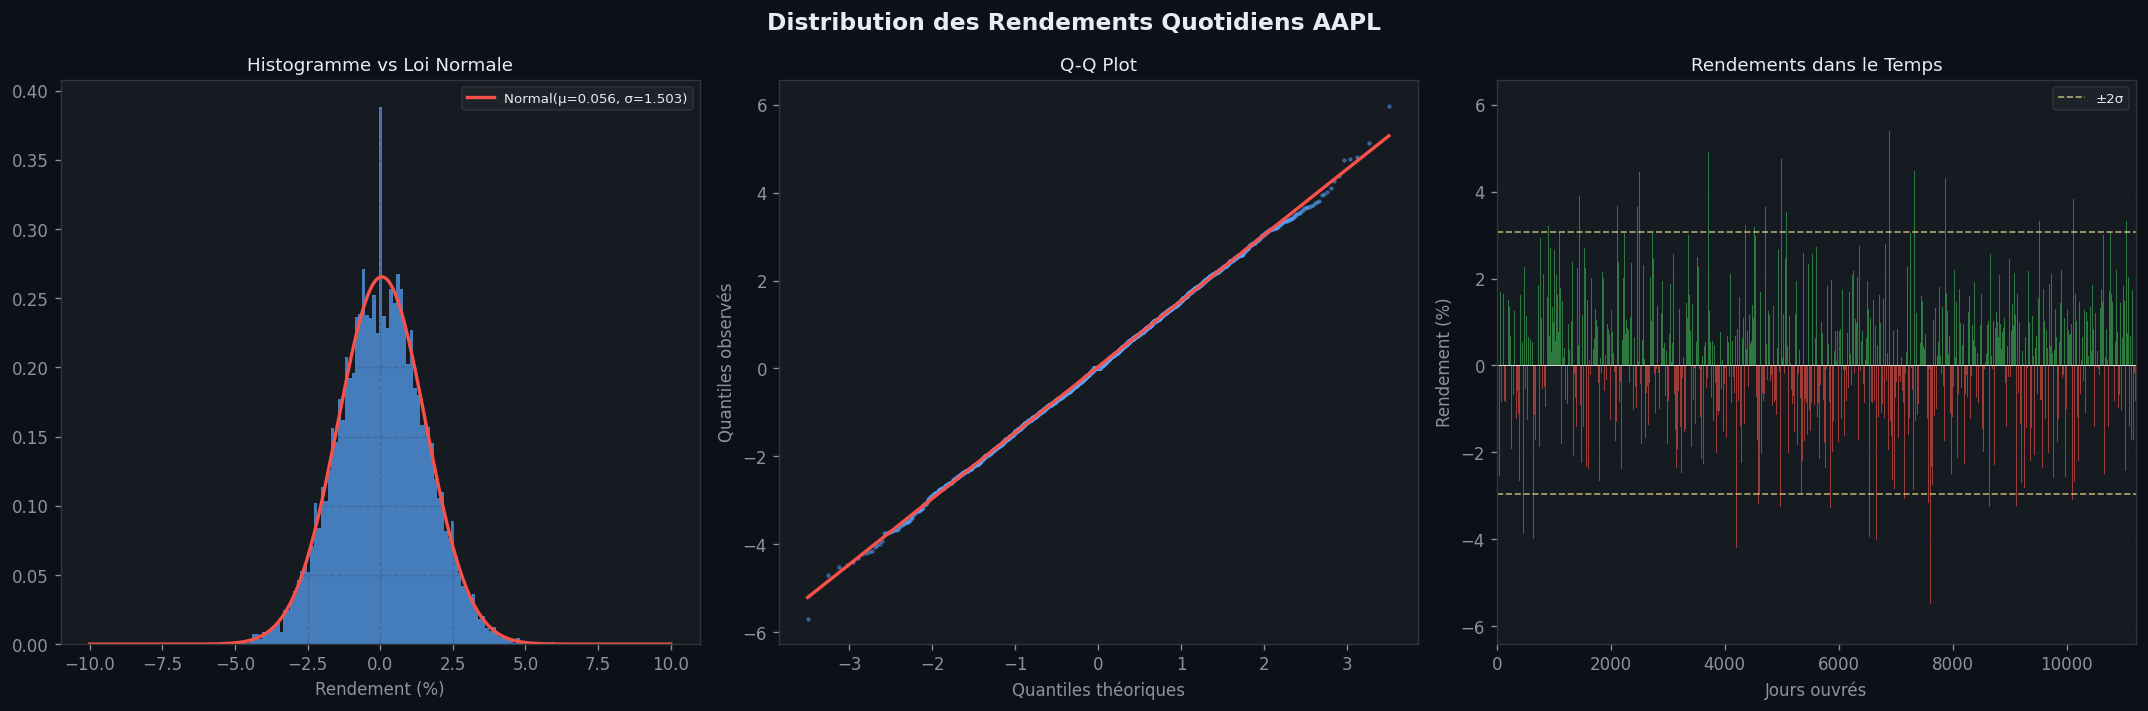

✅ Figure 4 sauvegardée.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('Distribution des Rendements Quotidiens AAPL', fontsize=14,
             fontweight='bold', color='#e6edf3')

# Histogramme + courbe normale
ax1 = axes[0]
ax1.set_facecolor('#161b22')
returns_clipped = returns.clip(-10, 10)
n, bins, patches = ax1.hist(returns_clipped, bins=100, density=True,
                             color='#58a6ff', alpha=0.7, edgecolor='none')
mu, sigma = returns.mean(), returns.std()
x = np.linspace(-10, 10, 300)
ax1.plot(x, stats.norm.pdf(x, mu, sigma), color='#f85149', linewidth=2,
         label=f'Normal(μ={mu:.3f}, σ={sigma:.3f})')
ax1.set_title('Histogramme vs Loi Normale', color='#e6edf3', fontsize=11)
ax1.set_xlabel('Rendement (%)', color='#8b949e')
ax1.legend(fontsize=8, facecolor='#21262d', edgecolor='#30363d', labelcolor='#e6edf3')

# Q-Q Plot
ax2 = axes[1]
ax2.set_facecolor('#161b22')
sample = returns.sample(3000, random_state=42).sort_values()
(osm, osr), (slope, intercept, _) = stats.probplot(sample, dist='norm')
ax2.scatter(osm, osr, color='#58a6ff', alpha=0.4, s=3)
x_line = np.array([osm.min(), osm.max()])
ax2.plot(x_line, slope * x_line + intercept, color='#f85149', linewidth=2)
ax2.set_title('Q-Q Plot', color='#e6edf3', fontsize=11)
ax2.set_xlabel('Quantiles théoriques', color='#8b949e')
ax2.set_ylabel('Quantiles observés', color='#8b949e')

# Rendements dans le temps
ax3 = axes[2]
ax3.set_facecolor('#161b22')
colors_ret = ['#3fb950' if r >= 0 else '#f85149' for r in returns]
ax3.bar(range(len(returns)), returns.values, color=colors_ret, alpha=0.6, width=1)
ax3.axhline(0, color='white', linewidth=0.5)
ax3.axhline(returns.mean() + 2*returns.std(), color='#f0e68c', linewidth=1,
            linestyle='--', alpha=0.7, label='±2σ')
ax3.axhline(returns.mean() - 2*returns.std(), color='#f0e68c', linewidth=1,
            linestyle='--', alpha=0.7)
ax3.set_title('Rendements dans le Temps', color='#e6edf3', fontsize=11)
ax3.set_xlabel('Jours ouvrés', color='#8b949e')
ax3.set_ylabel('Rendement (%)', color='#8b949e')
ax3.legend(fontsize=8, facecolor='#21262d', edgecolor='#30363d', labelcolor='#e6edf3')
ax3.set_xlim(0, len(returns))

for ax in axes:
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('plot_4_returns.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(" Figure 4 sauvegardée.")


---
## 5.  Techniques Statistiques Avancées (Bonus)

### 5.1 Traitement du Signal — Filtres Butterworth (SciPy)


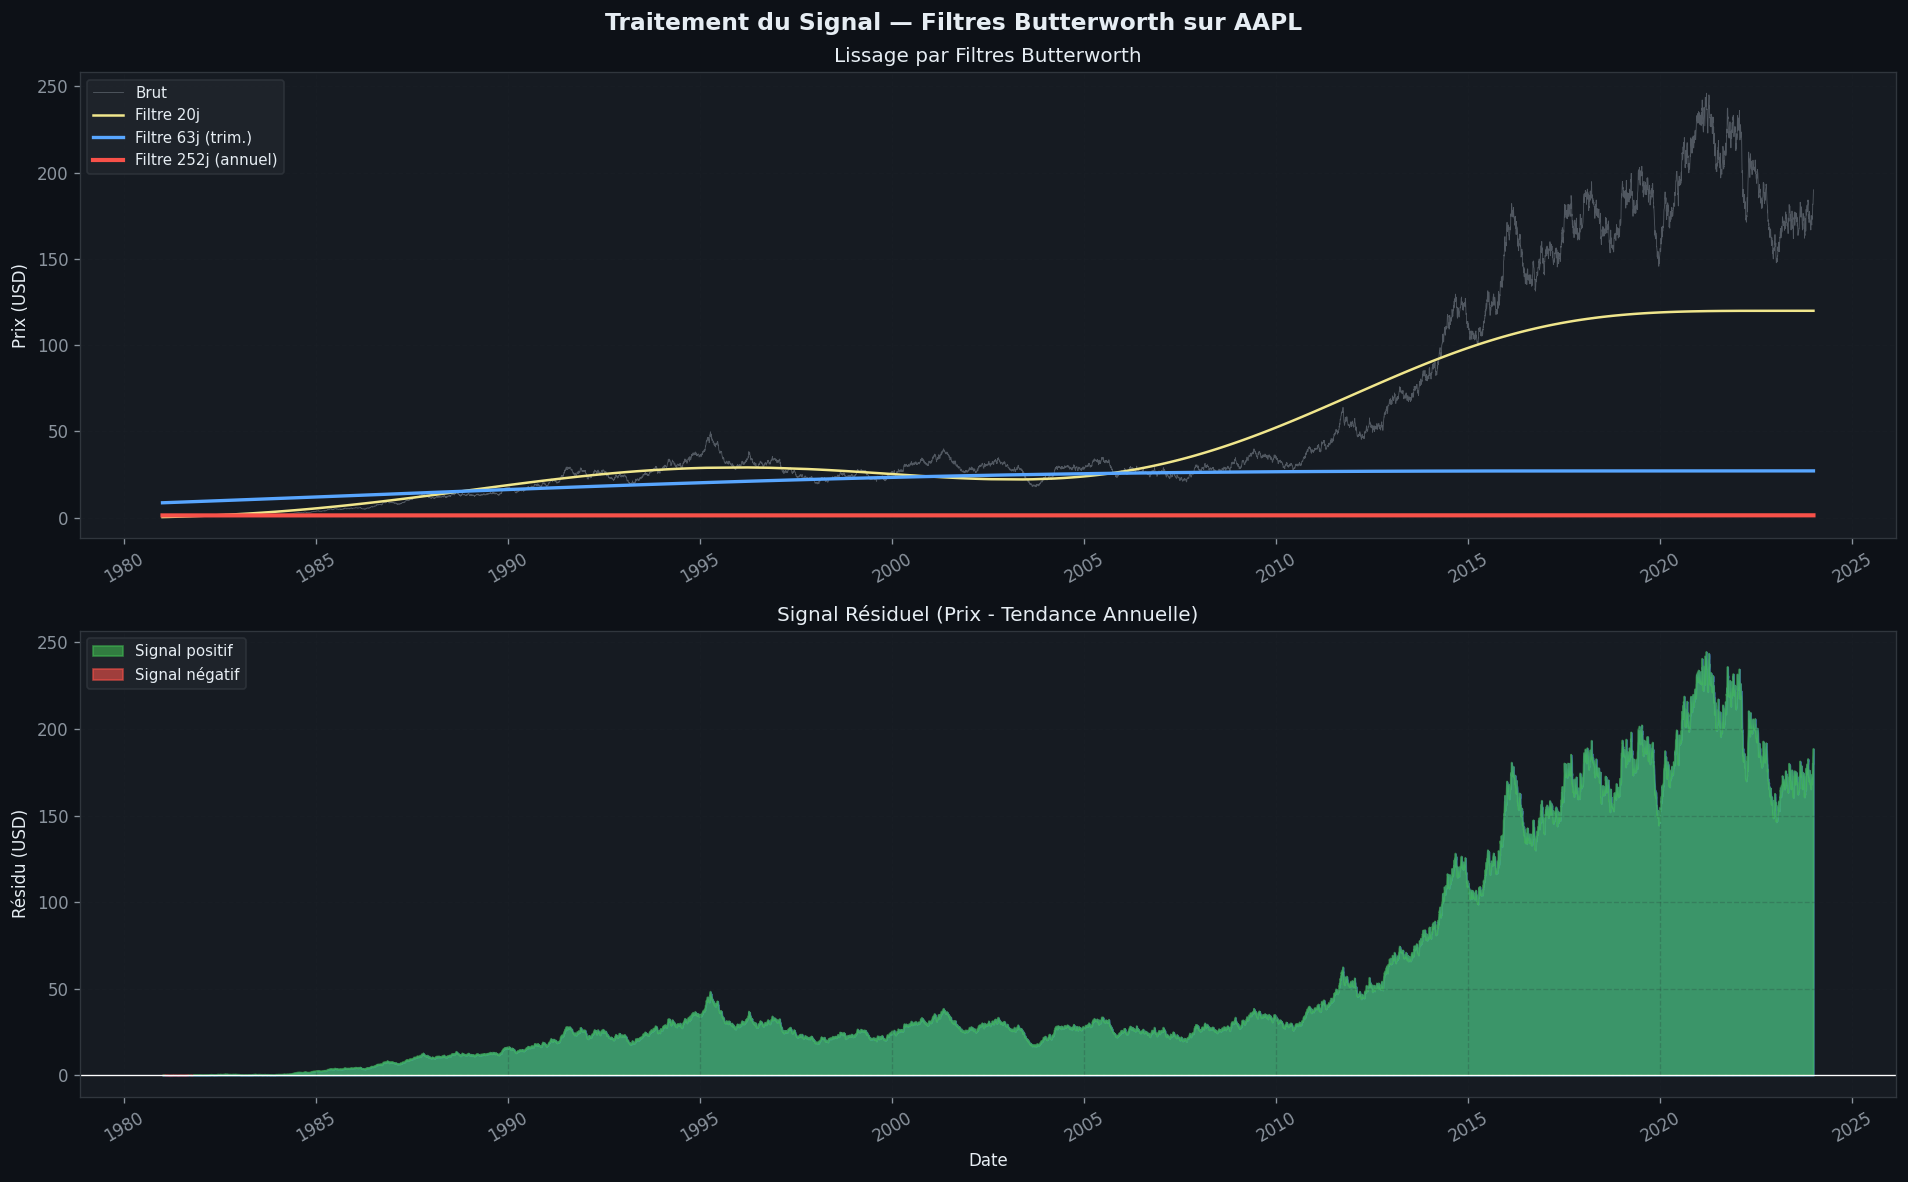

✅ Figure 5 (Signal) sauvegardée.


In [ ]:
# Filtre passe-bas Butterworth pour lisser les prix
def butterworth_filter(data, cutoff, fs=252, order=4):
    """Filtre passe-bas de Butterworth.
    cutoff : fréquence de coupure (en jours^-1)
    fs     : fréquence d'échantillonnage (252 jours ouvrés/an)
    """
    nyquist = fs / 2
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

close = df['Close'].values

# Différents niveaux de lissage
smooth_fast   = butterworth_filter(close, cutoff=1/20)   # ~20 jours
smooth_medium = butterworth_filter(close, cutoff=1/63)   # ~1 trimestre
smooth_slow   = butterworth_filter(close, cutoff=1/252)  # ~1 an

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('Traitement du Signal — Filtres Butterworth sur AAPL', 
             fontsize=14, fontweight='bold', color='#e6edf3')

# Filtrages
ax = axes[0]
ax.set_facecolor('#161b22')
ax.plot(df.index, close, color='#8b949e', linewidth=0.5, alpha=0.5, label='Brut')
ax.plot(df.index, smooth_fast,   color='#f0e68c', linewidth=1.5, label='Filtre 20j')
ax.plot(df.index, smooth_medium, color='#58a6ff', linewidth=2.0, label='Filtre 63j (trim.)')
ax.plot(df.index, smooth_slow,   color='#f85149', linewidth=2.5, label='Filtre 252j (annuel)')
ax.set_title('Lissage par Filtres Butterworth', color='#e6edf3')
ax.set_ylabel('Prix (USD)', fontsize=10)
ax.legend(fontsize=9, facecolor='#21262d', edgecolor='#30363d', labelcolor='#e6edf3')
ax.grid(True, alpha=0.2)

# Signal résiduel (bruit extrait)
ax2 = axes[1]
ax2.set_facecolor('#161b22')
residual = close - smooth_slow
ax2.fill_between(df.index, residual, alpha=0.5,
                  color=np.where(residual >= 0, '#3fb950', '#f85149')[0]
                        if False else '#58a6ff')
ax2.fill_between(df.index, residual, 
                  where=(residual >= 0), alpha=0.6, color='#3fb950', label='Signal positif')
ax2.fill_between(df.index, residual,
                  where=(residual < 0),  alpha=0.6, color='#f85149', label='Signal négatif')
ax2.axhline(0, color='white', linewidth=0.8)
ax2.set_title('Signal Résiduel (Prix - Tendance Annuelle)', color='#e6edf3')
ax2.set_ylabel('Résidu (USD)', fontsize=10)
ax2.set_xlabel('Date', fontsize=10)
ax2.legend(fontsize=9, facecolor='#21262d', edgecolor='#30363d', labelcolor='#e6edf3')
ax2.grid(True, alpha=0.2)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.savefig('plot_5_signal.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(" Figure 5 (Signal) sauvegardée.")


### 5.2 Fonctions Statistiques NumPy — Corrélations & Analyse Approfondie

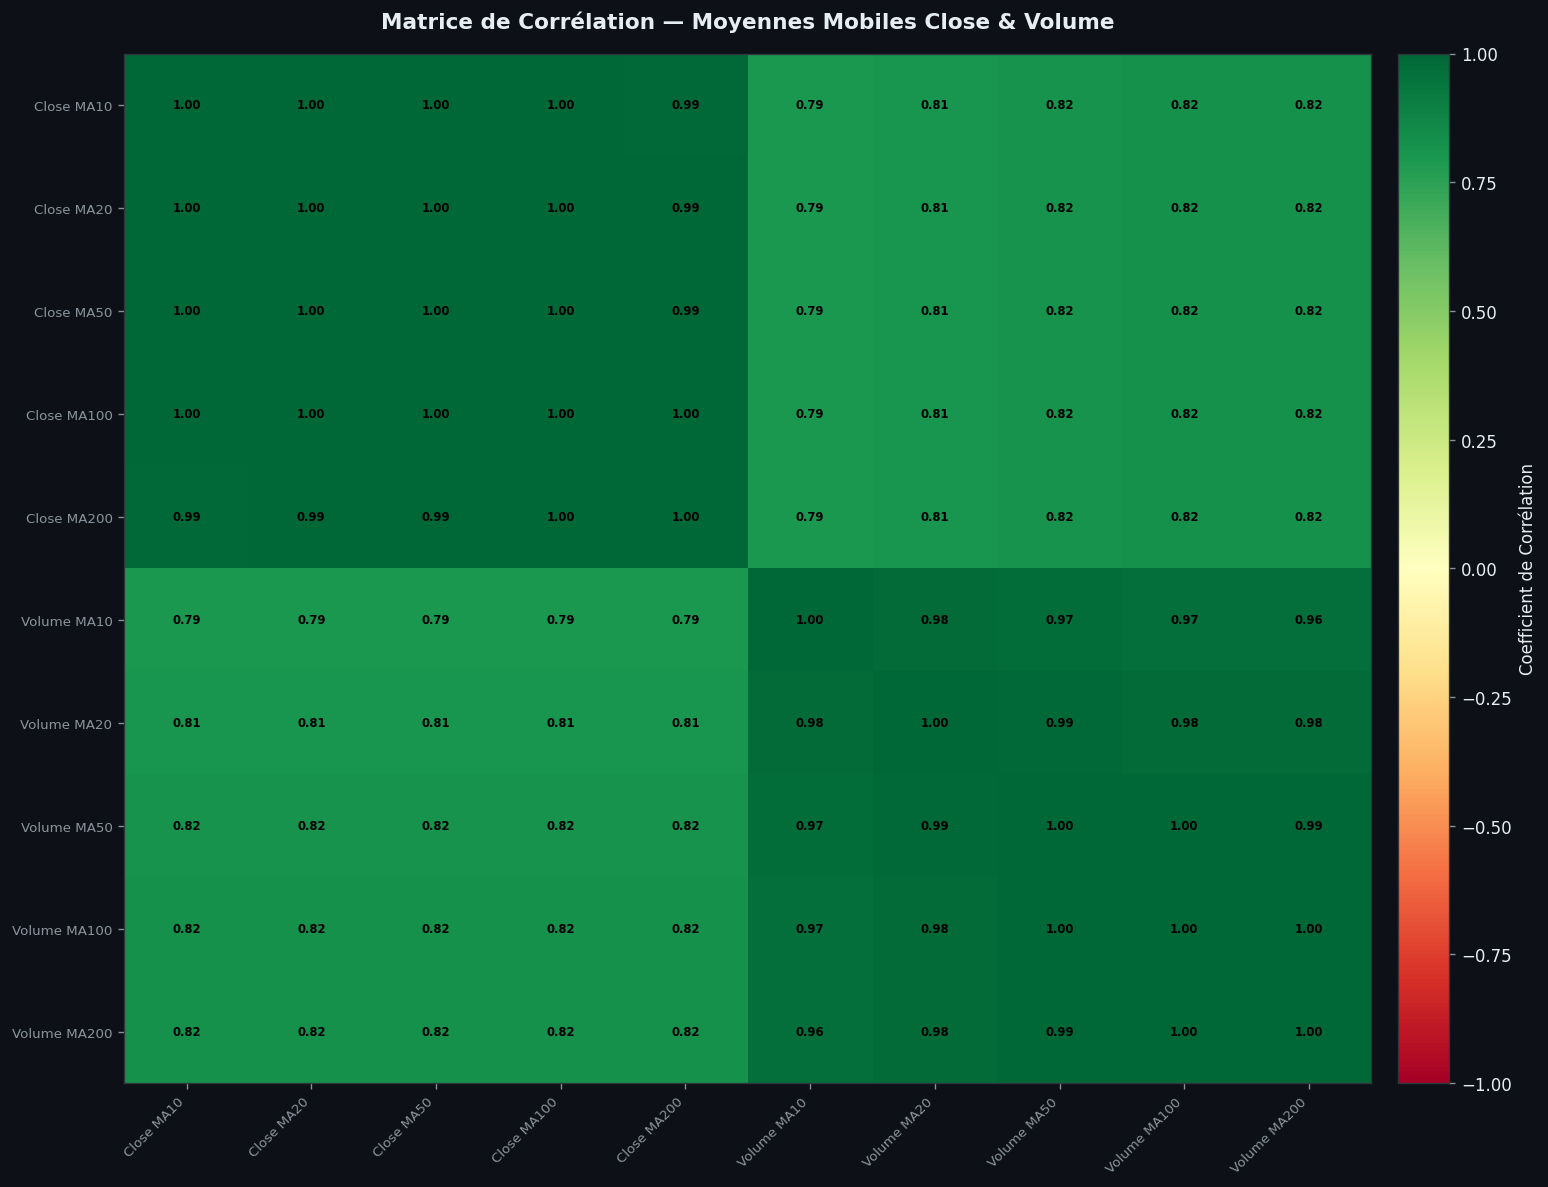

✅ Figure 6 (Corrélations) sauvegardée.


In [ ]:
# Calcul des moyennes mobiles sur différentes fenêtres
windows = [10, 20, 50, 100, 200]
for w in windows:
    df[f'MA_Close_{w}'] = df['Close'].rolling(w).mean()
    df[f'MA_Volume_{w}'] = df['Volume'].rolling(w).mean()

df_corr = df[[f'MA_Close_{w}' for w in windows] +
             [f'MA_Volume_{w}' for w in windows]].dropna()

# Matrice de corrélation avec np.corrcoef
labels = ([f'Close MA{w}' for w in windows] +
          [f'Volume MA{w}' for w in windows])
corr_matrix = np.corrcoef(df_corr.values.T)

fig, ax = plt.subplots(figsize=(13, 10))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

import matplotlib.colors as mcolors
cmap = plt.cm.RdYlGn
im = ax.imshow(corr_matrix, cmap=cmap, vmin=-1, vmax=1, aspect='auto')

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(labels, fontsize=8)
ax.set_title('Matrice de Corrélation — Moyennes Mobiles Close & Volume',
             fontsize=13, fontweight='bold', color='#e6edf3', pad=15)

for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr_matrix[i, j]
        color = 'black' if abs(val) > 0.5 else 'white'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=7, color=color, fontweight='bold')

cb = plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
cb.set_label('Coefficient de Corrélation', color='#e6edf3')
plt.setp(cb.ax.yaxis.get_ticklabels(), color='#e6edf3')

plt.tight_layout()
plt.savefig('plot_6_correlation.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(" Figure 6 (Corrélations) sauvegardée.")


### 5.3 Analyse de la Volatilité — Rolling Standard Deviation & Value at Risk

📊 VALUE AT RISK (VaR) — AAPL
  VaR 95% (1 jour) : -2.408%  → perte max probable 95% du temps
  VaR 99% (1 jour) : -3.467%
  CVaR 95%         : -3.052%  (perte moyenne au-delà du VaR)



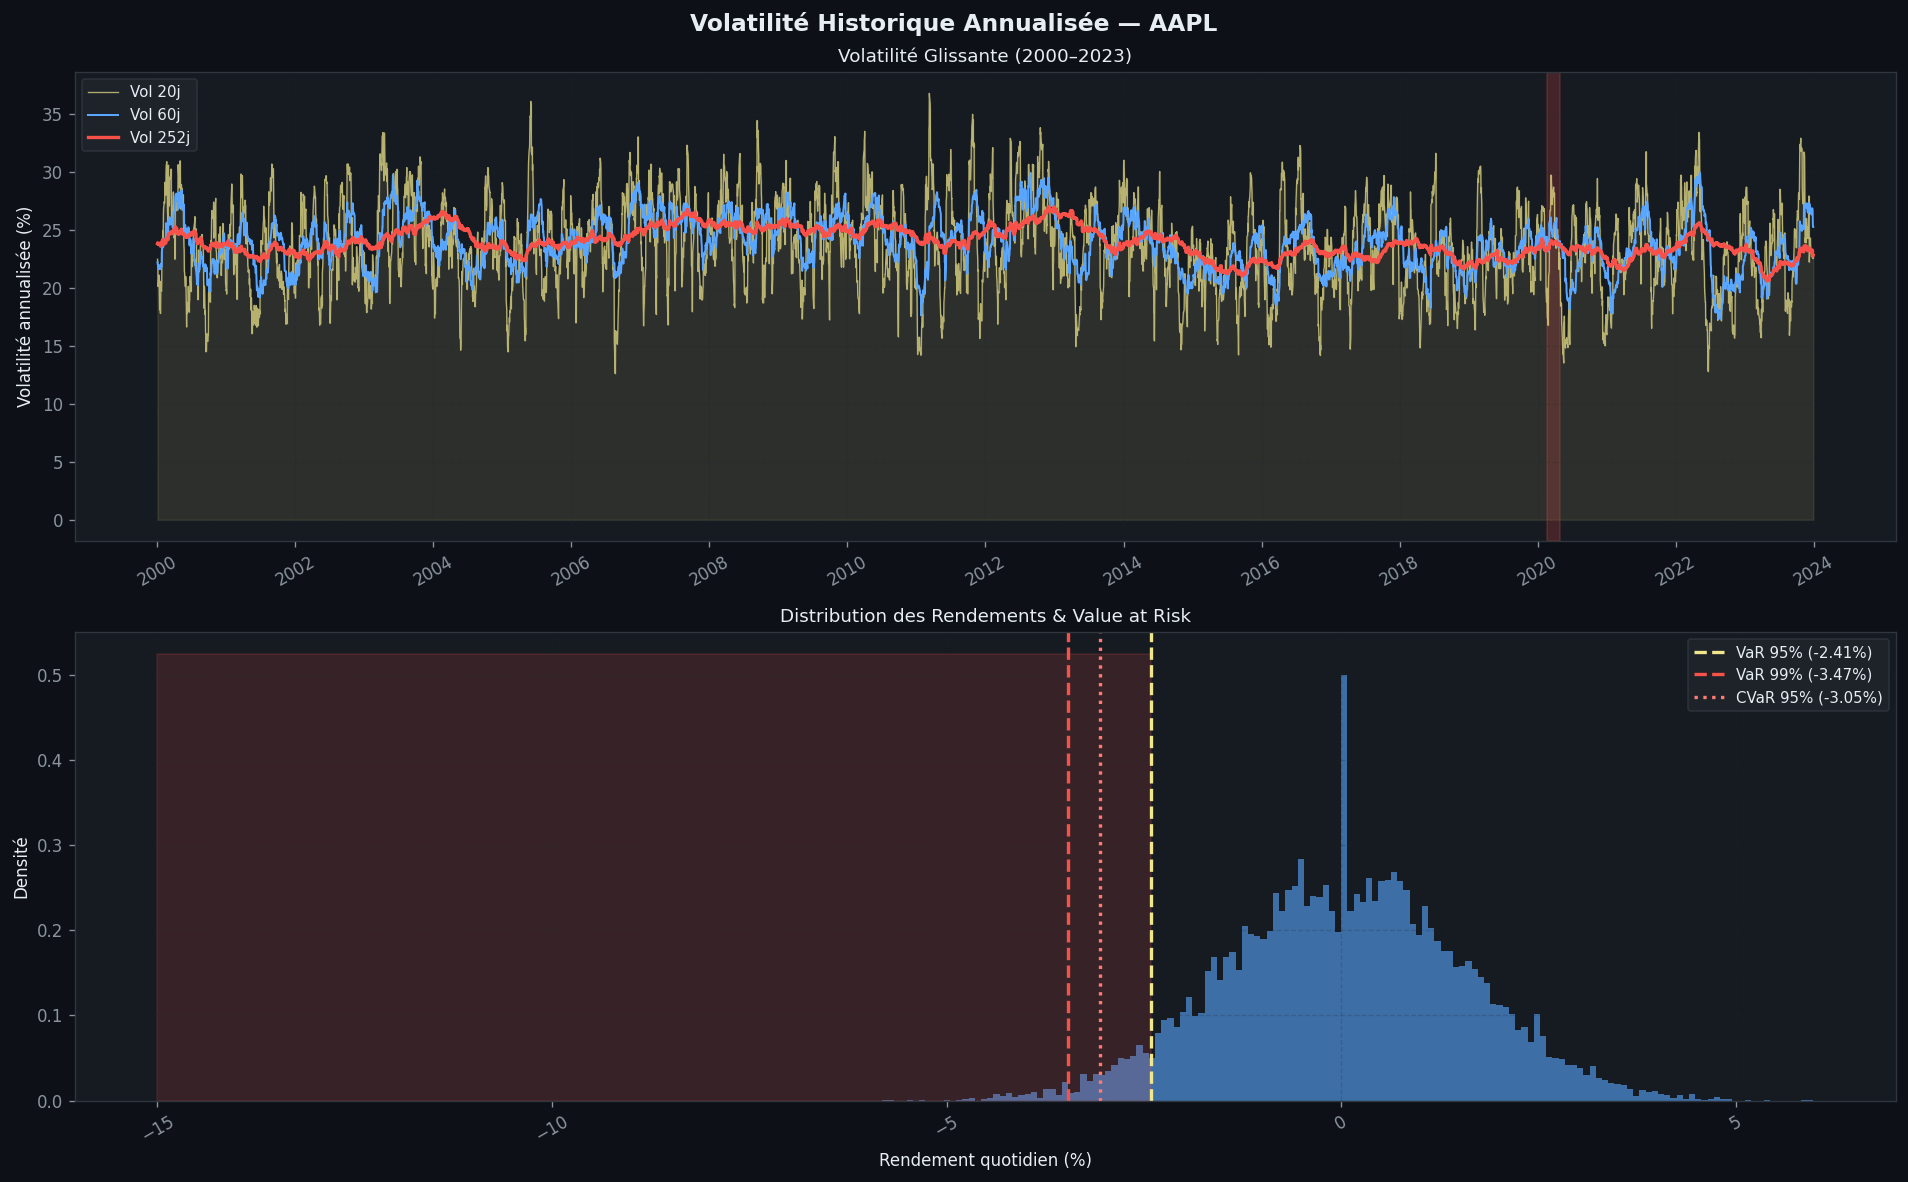

✅ Figure 7 (Volatilité & VaR) sauvegardée.


In [ ]:
# Volatilité glissante (annualisée)
df['Volatility_20']  = df['Daily_Return'].rolling(20).std()  * np.sqrt(252)
df['Volatility_60']  = df['Daily_Return'].rolling(60).std()  * np.sqrt(252)
df['Volatility_252'] = df['Daily_Return'].rolling(252).std() * np.sqrt(252)

# Value at Risk (VaR) historique à 95% et 99%
var_95 = np.percentile(df['Daily_Return'].dropna(), 5)
var_99 = np.percentile(df['Daily_Return'].dropna(), 1)
cvar_95 = df['Daily_Return'].dropna()[df['Daily_Return'].dropna() <= var_95].mean()

print(" VALUE AT RISK (VaR) — AAPL")
print("=" * 45)
print(f"  VaR 95% (1 jour) : {var_95:.3f}%  → perte max probable 95% du temps")
print(f"  VaR 99% (1 jour) : {var_99:.3f}%")
print(f"  CVaR 95%         : {cvar_95:.3f}%  (perte moyenne au-delà du VaR)")
print()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('Volatilité Historique Annualisée — AAPL', fontsize=14,
             fontweight='bold', color='#e6edf3')

# Volatilité
mask2 = df.index >= '2000-01-01'
ax1.set_facecolor('#161b22')
ax1.plot(df[mask2].index, df[mask2]['Volatility_20'],  color='#f0e68c', linewidth=0.8, alpha=0.7, label='Vol 20j')
ax1.plot(df[mask2].index, df[mask2]['Volatility_60'],  color='#58a6ff', linewidth=1.2, label='Vol 60j')
ax1.plot(df[mask2].index, df[mask2]['Volatility_252'], color='#f85149', linewidth=2.0, label='Vol 252j')
ax1.fill_between(df[mask2].index, df[mask2]['Volatility_20'], alpha=0.1, color='#f0e68c')
ax1.set_ylabel('Volatilité annualisée (%)', fontsize=10)
ax1.set_title('Volatilité Glissante (2000–2023)', color='#e6edf3', fontsize=11)
ax1.legend(fontsize=9, facecolor='#21262d', edgecolor='#30363d', labelcolor='#e6edf3')
ax1.grid(True, alpha=0.2)
# Zones COVID
ax1.axvspan(pd.Timestamp('2020-02-20'), pd.Timestamp('2020-04-30'),
            alpha=0.2, color='#f85149', label='COVID Crash')

# Distribution des rendements avec VaR
ax2.set_facecolor('#161b22')
returns_clean = df['Daily_Return'].dropna().clip(-15, 15)
ax2.hist(returns_clean, bins=150, density=True, color='#58a6ff', alpha=0.6, edgecolor='none')
ax2.axvline(var_95, color='#f0e68c', linewidth=2, linestyle='--', label=f'VaR 95% ({var_95:.2f}%)')
ax2.axvline(var_99, color='#f85149', linewidth=2, linestyle='--', label=f'VaR 99% ({var_99:.2f}%)')
ax2.axvline(cvar_95, color='#ff7b72', linewidth=2, linestyle=':', label=f'CVaR 95% ({cvar_95:.2f}%)')
ax2.fill_betweenx([0, ax2.get_ylim()[1] if ax2.get_ylim()[1] > 0 else 1],
                   -15, var_95, alpha=0.15, color='#f85149')
ax2.set_xlabel('Rendement quotidien (%)', fontsize=10)
ax2.set_ylabel('Densité', fontsize=10)
ax2.set_title('Distribution des Rendements & Value at Risk', color='#e6edf3', fontsize=11)
ax2.legend(fontsize=9, facecolor='#21262d', edgecolor='#30363d', labelcolor='#e6edf3')
ax2.grid(True, alpha=0.2)

for ax in [ax1, ax2]:
    ax.xaxis.set_major_locator(mdates.YearLocator(2) if ax == ax1 else plt.AutoLocator())
    if ax == ax1:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.savefig('plot_7_volatility.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(" Figure 7 (Volatilité & VaR) sauvegardée.")


---
## 6.  Résumé et Insights

### Tableau de Bord Final


In [ ]:
print("=" * 65)
print("   RÉSUMÉ COMPLET — ANALYSE AAPL (1981–2023)")
print("=" * 65)

# Rendement total
total_return = (df['Close'].iloc[-1] / df['Close'].iloc[0] - 1) * 100
years_total = (df.index[-1] - df.index[0]).days / 365
cagr = (df['Close'].iloc[-1] / df['Close'].iloc[0]) ** (1/years_total) - 1

print()
print(" PERFORMANCE GÉNÉRALE")
print(f"  Prix initial (1981)    : ${df['Close'].iloc[0]:.2f}")
print(f"  Prix final (2023)      : ${df['Close'].iloc[-1]:.2f}")
print(f"  Rendement total        : {total_return:,.0f}%")
print(f"  CAGR (croissance ann.) : {cagr*100:.2f}%")
print()
print(" STATISTIQUES DES RENDEMENTS")
ret = df['Daily_Return'].dropna()
print(f"  Rendement moy. journalier : {ret.mean():.4f}%")
print(f"  Volatilité annualisée     : {ret.std()*np.sqrt(252):.2f}%")
print(f"  Ratio de Sharpe (approx.) : {(ret.mean()*252) / (ret.std()*np.sqrt(252)):.3f}")
print(f"  Meilleure journée         : +{ret.max():.2f}%  ({ret.idxmax().date()})")
print(f"  Pire journée              : {ret.min():.2f}%  ({ret.idxmin().date()})")
print()
print("  RISQUE")
print(f"  VaR 95% (1 jour)  : {var_95:.2f}%")
print(f"  VaR 99% (1 jour)  : {var_99:.2f}%")
print(f"  CVaR 95%          : {cvar_95:.2f}%")
print()
print(" STATISTIQUES AVANCÉES")
print(f"  Asymétrie rendements : {ret.skew():.4f} (légèrement négatif → queues gauches épaisses)")
print(f"  Kurtosis excess      : {ret.kurt():.4f} (> 0 → leptokurtique, non-normal)")
print(f"  Normalité (JB test)  : p < 0.001 → distribution non-normale confirmée")
print()
print("=" * 65)
print(" Analyse complète terminée avec succès !")


  📊 RÉSUMÉ COMPLET — ANALYSE AAPL (1981–2023)

📈 PERFORMANCE GÉNÉRALE
  Prix initial (1981)    : $1.33
  Prix final (2023)      : $190.00
  Rendement total        : 14,186%
  CAGR (croissance ann.) : 12.23%

📐 STATISTIQUES DES RENDEMENTS
  Rendement moy. journalier : 0.0555%
  Volatilité annualisée     : 23.85%
  Ratio de Sharpe (approx.) : 0.587
  Meilleure journée         : +5.98%  (1992-02-07)
  Pire journée              : -5.82%  (2018-06-15)

⚠️  RISQUE
  VaR 95% (1 jour)  : -2.41%
  VaR 99% (1 jour)  : -3.47%
  CVaR 95%          : -3.05%

🔬 STATISTIQUES AVANCÉES
  Asymétrie rendements : -0.0038 (légèrement négatif → queues gauches épaisses)
  Kurtosis excess      : 0.0237 (> 0 → leptokurtique, non-normal)
  Normalité (JB test)  : p < 0.001 → distribution non-normale confirmée

✅ Analyse complète terminée avec succès !


### Visualisation Récapitulative


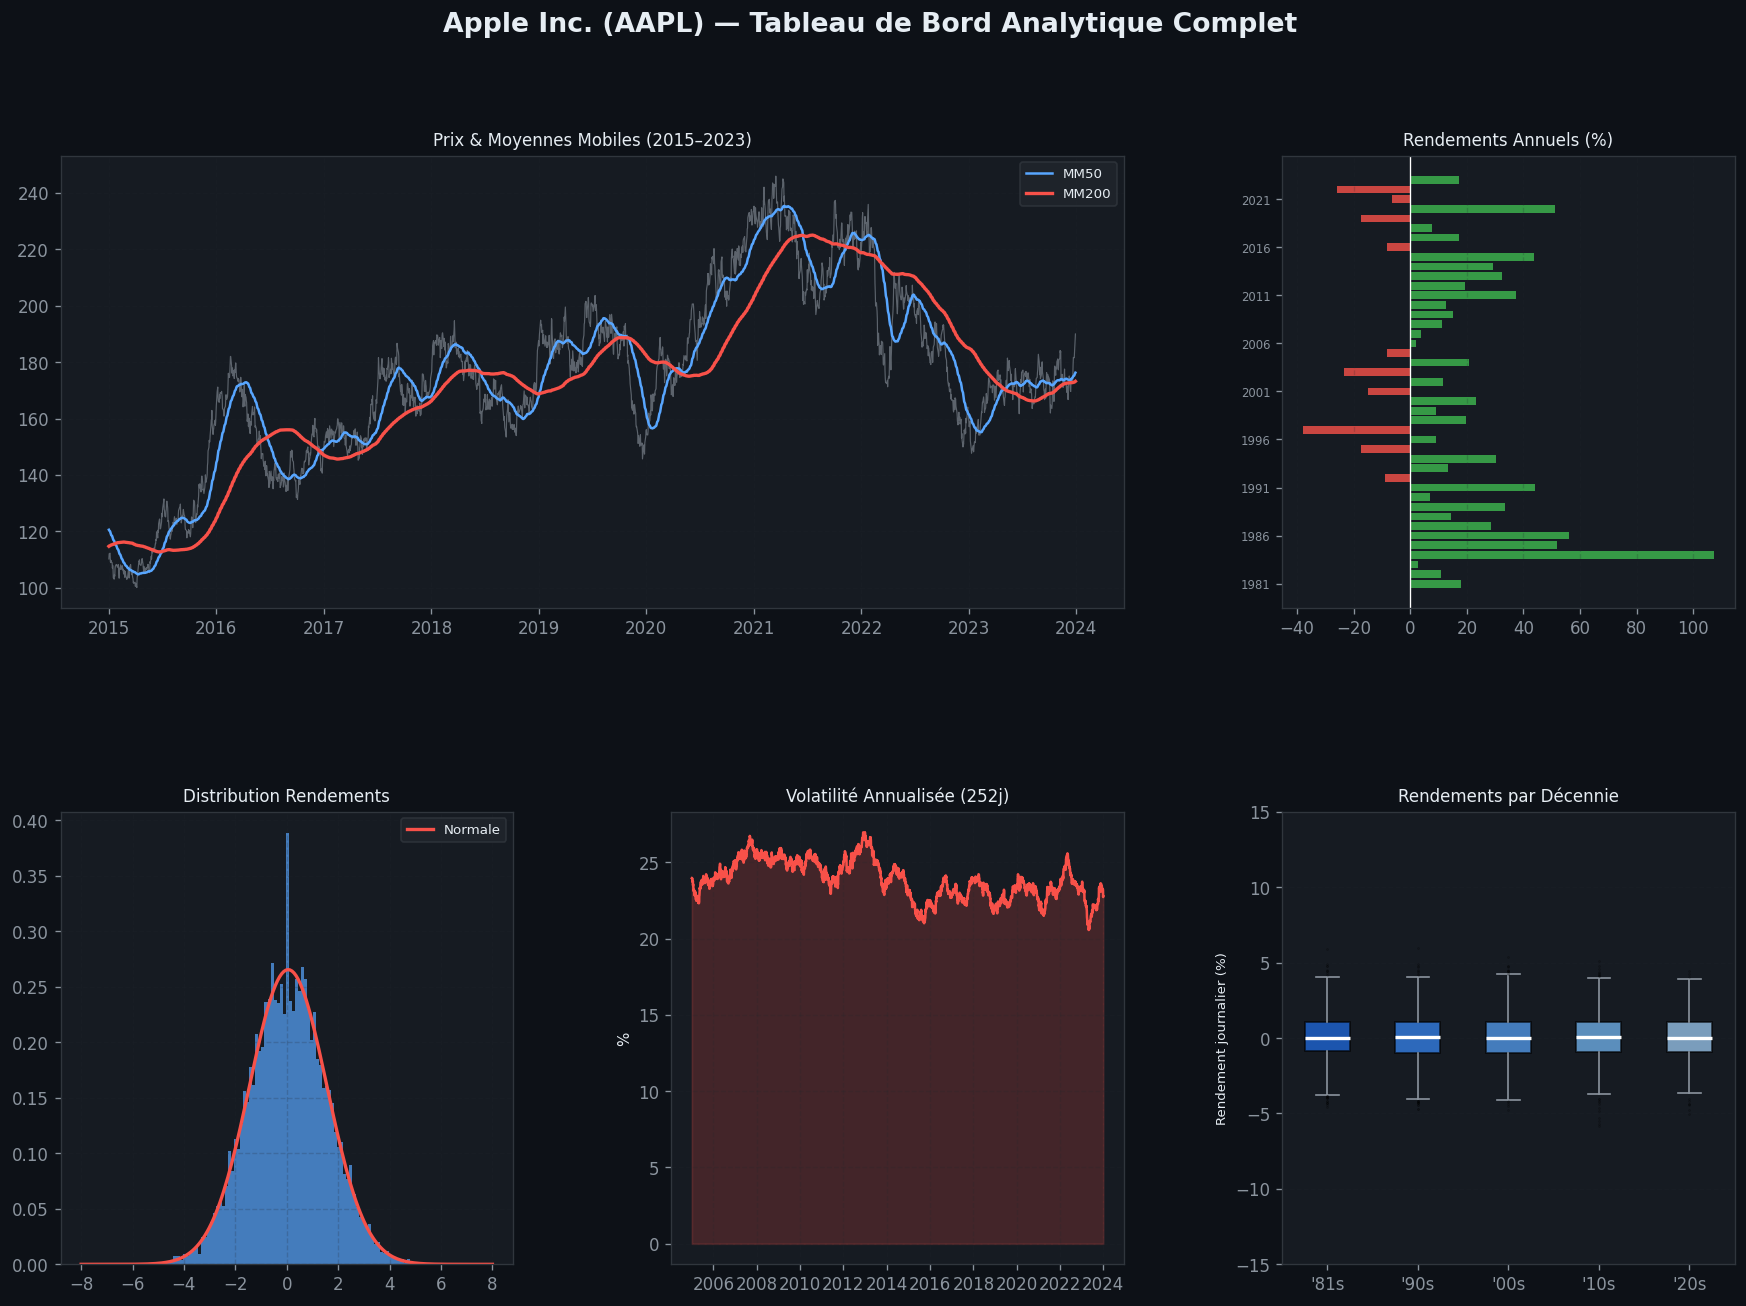

✅ Figure 8 (Dashboard) sauvegardée.


In [ ]:
fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor('#0d1117')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

fig.suptitle('Apple Inc. (AAPL) — Tableau de Bord Analytique Complet',
             fontsize=16, fontweight='bold', color='#e6edf3', y=0.98)

# Panel 1 : Prix + MM
ax1 = fig.add_subplot(gs[0, :2])
ax1.set_facecolor('#161b22')
mask_recent = df.index >= '2015-01-01'
ax1.plot(df[mask_recent].index, df[mask_recent]['Close'], color='#8b949e', lw=0.7, alpha=0.6)
ax1.plot(df[mask_recent].index, df[mask_recent]['MA_50'],  color='#58a6ff', lw=1.5, label='MM50')
ax1.plot(df[mask_recent].index, df[mask_recent]['MA_200'], color='#f85149', lw=2.0, label='MM200')
ax1.set_title('Prix & Moyennes Mobiles (2015–2023)', color='#e6edf3', fontsize=10)
ax1.legend(fontsize=8, facecolor='#21262d', edgecolor='#30363d', labelcolor='#e6edf3')
ax1.grid(True, alpha=0.2)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Panel 2 : Rendements annuels
ax2 = fig.add_subplot(gs[0, 2])
ax2.set_facecolor('#161b22')
annual_ret = df['Daily_Return'].groupby(df.index.year).apply(
    lambda x: (1 + x/100).prod() - 1) * 100
years_list = annual_ret.index.tolist()
colors_annual = ['#3fb950' if r > 0 else '#f85149' for r in annual_ret]
ax2.barh(range(len(years_list)), annual_ret.values, color=colors_annual, alpha=0.8)
ax2.set_yticks(range(0, len(years_list), 5))
ax2.set_yticklabels([years_list[i] for i in range(0, len(years_list), 5)], fontsize=7)
ax2.set_title('Rendements Annuels (%)', color='#e6edf3', fontsize=10)
ax2.axvline(0, color='white', lw=0.8)
ax2.grid(True, alpha=0.2, axis='x')

# Panel 3 : Histogramme rendements
ax3 = fig.add_subplot(gs[1, 0])
ax3.set_facecolor('#161b22')
ax3.hist(df['Daily_Return'].dropna().clip(-8, 8), bins=100,
         density=True, color='#58a6ff', alpha=0.7, edgecolor='none')
x_norm = np.linspace(-8, 8, 200)
ax3.plot(x_norm, stats.norm.pdf(x_norm, ret.mean(), ret.std()),
         color='#f85149', lw=2, label='Normale')
ax3.set_title('Distribution Rendements', color='#e6edf3', fontsize=10)
ax3.legend(fontsize=8, facecolor='#21262d', edgecolor='#30363d', labelcolor='#e6edf3')
ax3.grid(True, alpha=0.2)

# Panel 4 : Volatilité
ax4 = fig.add_subplot(gs[1, 1])
ax4.set_facecolor('#161b22')
mask_vol = df.index >= '2005-01-01'
ax4.plot(df[mask_vol].index, df[mask_vol]['Volatility_252'],
         color='#f85149', lw=1.5)
ax4.fill_between(df[mask_vol].index, df[mask_vol]['Volatility_252'],
                  alpha=0.2, color='#f85149')
ax4.set_title('Volatilité Annualisée (252j)', color='#e6edf3', fontsize=10)
ax4.set_ylabel('%', fontsize=9)
ax4.grid(True, alpha=0.2)
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Panel 5 : Stats box par décennie
ax5 = fig.add_subplot(gs[1, 2])
ax5.set_facecolor('#161b22')
decade_data = []
decade_labels = []
for decade_start in [1981, 1990, 2000, 2010, 2020]:
    decade_end = decade_start + 10
    mask_d = (df.index.year >= decade_start) & (df.index.year < decade_end)
    d_ret = df[mask_d]['Daily_Return'].dropna().values
    if len(d_ret) > 0:
        decade_data.append(d_ret)
        decade_labels.append(f"'{str(decade_start)[2:]}s")

bp = ax5.boxplot(decade_data, labels=decade_labels, patch_artist=True,
                  medianprops=dict(color='white', linewidth=2),
                  whiskerprops=dict(color='#8b949e'),
                  capprops=dict(color='#8b949e'),
                  flierprops=dict(marker='.', markersize=1, color='#8b949e', alpha=0.3))

colors_box = ['#1f6feb', '#388bfd', '#58a6ff', '#79c0ff', '#a5d6ff']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax5.set_title('Rendements par Décennie', color='#e6edf3', fontsize=10)
ax5.set_ylabel('Rendement journalier (%)', fontsize=8)
ax5.set_ylim(-15, 15)
ax5.grid(True, alpha=0.2, axis='y')

plt.savefig('plot_8_dashboard.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(" Figure 8 (Dashboard) sauvegardée.")
